# Point-in-Time Universe Construction

This notebook builds only the eligible universe; it does not compute signals or run a backtest.

In [8]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = '../data/sharadar.db'
AS_OF = '2024-01-31'

# Make the standalone V2 source importable when launched from the V2 directory.
sys.path.insert(0, str(Path.cwd().parent / 'scripts'))
from build_universe import get_universe

A universe is the set of securities eligible for a study at a specific date. Point-in-time eligibility matters because using later listings, prices, or delisting knowledge would introduce look-ahead and survivorship bias.

In [9]:
universe = get_universe(DB_PATH, AS_OF)
print('Shape:', universe.shape)
universe.head(10)

Shape: (1003, 8)


,ticker,permaticker,name,exchange,firstpricedate,lastpricedate,last_close,median_dollar_volume
0,LQDT,195392,LIQUIDITY SERVICES INC,NASDAQ,2006-02-27,2026-09-04,12.84,7.347060e+05
1,DAKT,197518,DAKTRONICS INC,NASDAQ,1994-02-10,2026-09-04,7.94,1.636335e+06
2,LPX,199570,LOUISIANA-PACIFIC CORP,NYSE,1986-01-01,2026-09-04,8.54,1.518856e+07
3,KMT,199599,KENNAMETAL INC,NYSE,1987-11-05,2026-09-04,27.80,1.958208e+07
4,KMX,195621,CARMAX INC,NYSE,1997-02-04,2026-09-04,23.30,3.827937e+07
5,CHRW,196783,C H ROBINSON WORLDWIDE INC,NASDAQ,1997-10-16,2026-09-04,53.25,9.136800e+07
6,KO,199839,COCA COLA CO,NYSE,1986-01-01,2026-09-04,54.47,1.055615e+09
7,CI,198962,CIGNA GROUP,NYSE,1986-01-01,2026-09-04,34.04,1.234001e+08
8,CIEN,197303,CIENA CORP,NYSE,1997-02-07,2026-09-04,16.01,5.908050e+07
9,LOW,199568,LOWES COMPANIES INC,NYSE,1986-01-01,2026-09-04,24.05,2.974981e+08


These distributions show the price and liquidity characteristics of the securities that survived every eligibility rule. Log-scaled x-axes make the wide cross-sectional ranges readable.

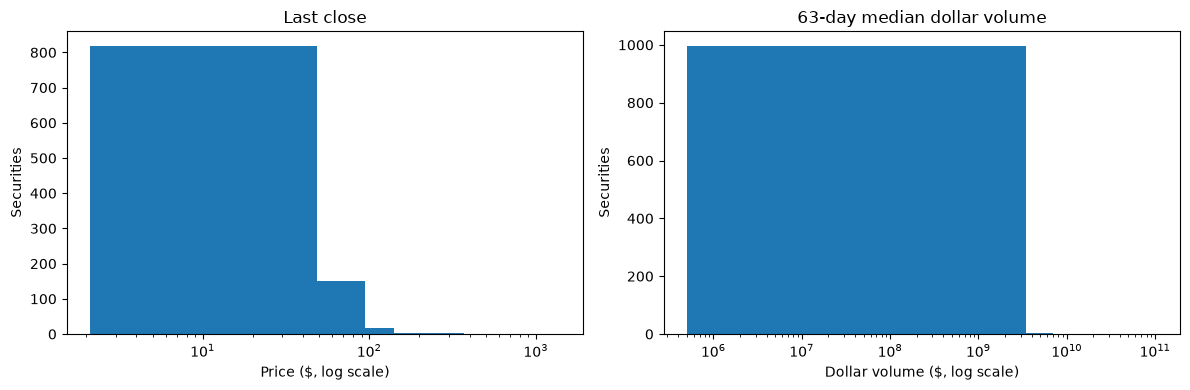

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(universe['last_close'], bins=30)
axes[0].set_xscale('log')
axes[0].set_title('Last close')
axes[0].set_xlabel('Price ($, log scale)')
axes[0].set_ylabel('Securities')
axes[1].hist(universe['median_dollar_volume'], bins=30)
axes[1].set_xscale('log')
axes[1].set_title('63-day median dollar volume')
axes[1].set_xlabel('Dollar volume ($, log scale)')
axes[1].set_ylabel('Securities')
plt.tight_layout()
plt.show()

These checks summarize the resulting universe and expose the exclusion funnel recorded by `get_universe`. Unexpectedly small counts or missing distributions should be investigated before using the universe.

In [14]:
print('Total securities:', len(universe))
print('Securities by exchange:')
print(universe['exchange'].value_counts())
print('Last close median/p10/p90:', universe['last_close'].median(), universe['last_close'].quantile(.10), universe['last_close'].quantile(.90))
print('Dollar volume median/p10/p90:', universe['median_dollar_volume'].median(), universe['median_dollar_volume'].quantile(.10), universe['median_dollar_volume'].quantile(.90))
print('Exclusion funnel:')
funnel = pd.DataFrame(universe.attrs.get('funnel', []))
display(funnel)
if len(universe) == 0:
    print('FLAG: no securities survived; check DB_PATH and data coverage.')

Total securities: 1003
Securities by exchange:
exchange
NYSE       568
NASDAQ     426
NYSEMKT      9
Name: count, dtype: int64
Last close median/p10/p90: 26.0 9.428 60.01000000000002
Dollar volume median/p10/p90: 13367227.499999998 1215377.6 216621160.00000003
Exclusion funnel:


,stage,count,excluded
0,started,13523,0
1,listing_status,3426,10097
2,price_floor,1124,2302
3,liquidity_and_history,1003,121
4,identity,1003,0


Running the same construction at separated dates is a basic point-in-time sanity check. Counts should vary as listings, prices, liquidity, and history change.

In [15]:
for check_date in ['2005-01-31', '2015-01-31', '2024-01-31']:
    frame = get_universe(DB_PATH, check_date)
    print(check_date, '->', len(frame), 'securities')

2005-01-31 -> 2326 securities
2015-01-31 -> 1734 securities
2024-01-31 -> 1093 securities


This universe does not guarantee survivorship-free terminal returns (capability: PARTIAL), perfect ticker continuity across reorganizations (UNSUPPORTED), or S&P 400/600 membership (UNSUPPORTED). These limitations are recorded in the capability registry; they do not block this universe for the three planned signals.